# 交易策略对比分析

使用测试脚本中的最优配置，计算和可视化 Long Only、Sign(R) 和 MACD 三个策略的累积收益率对比

## Section 1: 导入必需的库

In [169]:
%pip install -q matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [170]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 设置项目根路径（必须是绝对路径）
ROOT = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project')
# 输出目录 - 这个 notebook 所在的文件夹
OUTPUT_DIR = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project/reproduction_of_figures')

# 添加 module 搜索路径
sys.path.insert(0, str(ROOT))

# 导入基础配置和函数
from data_loader import load_clc_full
from config import ASSET_CLASSES, BP, TRADING_DAYS, SIGN_LOOKBACK, EXCLUDED_CONTRACTS, SOURCE_OVERRIDES
from metrics import compute_metrics, max_drawdown_from_path, cagr_from_path

# 设置绘图风格
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print(f'✅ 项目根目录: {ROOT}')
print(f'✅ 输出目录: {OUTPUT_DIR}')
print(f'✅ 当前工作目录: {Path.cwd()}')


✅ 项目根目录: /Users/ladymie/Documents/GitHub/IEOR4733_Project
✅ 输出目录: /Users/ladymie/Documents/GitHub/IEOR4733_Project/reproduction_of_figures
✅ 当前工作目录: /Users/ladymie/Documents/GitHub/IEOR4733_Project/reproduction_of_figures


## Section 2: 导入策略配置并定义计算函数


In [171]:
def build_a2c_results_by_asset(pnl_a2c_by_ticker, ticker_to_asset):
    """转换 A2C 输出格式为与其他策略一致的格式"""
    results = {}
    asset_classes = ['Commodity', 'Equity Index', 'Fixed Income', 'Forex']

    for asset in asset_classes:
        series_list = []

        for ticker, df in pnl_a2c_by_ticker.items():
            if ticker_to_asset.get(ticker) != asset:
                continue
            if df is None or len(df) == 0:
                continue
            if not all(c in df.columns for c in ['date', 'net_pnl']):
                continue

            s = pd.Series(df['net_pnl'].values, index=pd.to_datetime(df['date']))
            series_list.append(s)

        if series_list:
            port_series = pd.DataFrame(series_list).T.sort_index().mean(axis=1)
            dates = port_series.index.to_numpy()
            wealth = 1.0 + np.cumsum(port_series.values)
            results[asset] = (dates, wealth)
        else:
            results[asset] = (None, None)

    # All
    all_ticker_series = []
    for ticker, df in pnl_a2c_by_ticker.items():
        if df is None or len(df) == 0:
            continue
        if not all(c in df.columns for c in ['date', 'net_pnl']):
            continue
        s = pd.Series(df['net_pnl'].values, index=pd.to_datetime(df['date']))
        all_ticker_series.append(s)

    if all_ticker_series:
        port_series_all = pd.DataFrame(all_ticker_series).T.sort_index().mean(axis=1)
        results['All'] = (
            port_series_all.index.to_numpy(),
            1.0 + np.cumsum(port_series_all.values)
        )
    else:
        results['All'] = (None, None)

    return results

print("✅ A2C 结果转换函数已定义")

✅ A2C 结果转换函数已定义


In [172]:
# 导入各策略的最优配置（来自测试脚本）
sys.path.insert(0, str(ROOT / 'tests'))
sys.path.insert(0, str(ROOT / 'tests_MACD'))
sys.path.insert(0, str(ROOT / 'tests_Signr'))

try:
    import frontier_40plus_enumeration as fe_long
    LONG_OVERRIDES = fe_long.LEGACY_EXPERIMENTAL_OVERRIDES_LONG
    LONG_EXCLUDED = fe_long.LEGACY_EXPERIMENTAL_EXCLUDED_LONG
except ImportError as e:
    print(f"⚠️  无法导入 Long 配置: {e}")
    LONG_OVERRIDES = SOURCE_OVERRIDES
    LONG_EXCLUDED = EXCLUDED_CONTRACTS

try:
    import frontier_40plus_enumeration_macd as fe_macd
    MACD_OVERRIDES = fe_macd.LEGACY_EXPERIMENTAL_OVERRIDES_MACD
    MACD_EXCLUDED = fe_macd.LEGACY_EXPERIMENTAL_EXCLUDED_MACD
except ImportError as e:
    print(f"⚠️  无法导入 MACD 配置: {e}")
    MACD_OVERRIDES = SOURCE_OVERRIDES
    MACD_EXCLUDED = EXCLUDED_CONTRACTS

try:
    import frontier_40plus_enumeration_signr as fe_signr
    SIGNR_OVERRIDES = fe_signr.LEGACY_EXPERIMENTAL_OVERRIDES_SIGNR
    SIGNR_EXCLUDED = fe_signr.LEGACY_EXPERIMENTAL_EXCLUDED_SIGNR
except ImportError as e:
    print(f"⚠️  无法导入 Sign(R) 配置: {e}")
    SIGNR_OVERRIDES = SOURCE_OVERRIDES
    SIGNR_EXCLUDED = EXCLUDED_CONTRACTS

# 导入计算函数
from baseline_run import load_contracts, compute_contract_returns
import pandas as pd

# 参数设置
DEFAULT_SIGMA_TGT = 0.063
# 论文 Table 3 测试期间（2016-2019）
# 完整历史期间见 config.py（2011-01-01 ~ 2019-12-31）
TEST_START = '2011-01-01'
TEST_END = '2019-12-31'

ASSET_CLASSES_LIST = ['Commodity', 'Equity Index', 'Fixed Income', 'Forex']

def build_portfolio_series(raw_data, strat_name, sigma_tgt):
    """构造与组合收益一致、且按日期升序排序的组合收益序列。"""
    series = []
    for rd in raw_data:
        Rt = compute_contract_returns(rd, strat_name, sigma_tgt)
        start, t1, dates = rd['start'], rd['t1'], rd['dates']
        slc = Rt[start:t1 + 1]
        aligned_dates = pd.to_datetime(dates[:len(slc)])
        series.append(pd.Series(slc[:len(aligned_dates)], index=aligned_dates))
    if not series:
        return None
    df_all = pd.DataFrame(series)
    return df_all.T.sort_index().mean(axis=1)

def calculate_strategy_returns_by_asset(strat_name, overrides=None, excluded=None):
    """按资产类别分别计算策略的累积收益率
    
    返回字典格式：
    {
        'Commodity': (dates, wealth_path),
        'Equity Index': (dates, wealth_path),
        'Fixed Income': (dates, wealth_path),
        'FX': (dates, wealth_path),
        'All': (dates, wealth_path)
    }
    其中 wealth_path 是累积财富序列：W_t = 1 + cumsum(R_t)
    dates 是对应的日期数组
    """
    if overrides is None:
        overrides = {'Long': LONG_OVERRIDES, 'Sign(R)': SIGNR_OVERRIDES, 'MACD': MACD_OVERRIDES}.get(strat_name, SOURCE_OVERRIDES)
    if excluded is None:
        excluded = {'Long': LONG_EXCLUDED, 'Sign(R)': SIGNR_EXCLUDED, 'MACD': MACD_EXCLUDED}.get(strat_name, EXCLUDED_CONTRACTS)
    
    results = {}
    all_contracts = []
    
    for ac_name in ASSET_CLASSES_LIST:
        raw = load_contracts(ac_name, TEST_START, TEST_END, excluded, overrides)
        if raw:
            port_series = build_portfolio_series(raw, strat_name, DEFAULT_SIGMA_TGT)
            if port_series is not None and len(port_series) > 0:
                dates = port_series.index.to_numpy()
                wealth = 1.0 + np.cumsum(port_series.values)
                results[ac_name] = (dates, wealth)
                all_contracts.extend(raw)
            else:
                results[ac_name] = (None, None)
        else:
            results[ac_name] = (None, None)
    
    if all_contracts:
        port_series_all = build_portfolio_series(all_contracts, strat_name, DEFAULT_SIGMA_TGT)
        if port_series_all is not None and len(port_series_all) > 0:
            dates_all = port_series_all.index.to_numpy()
            wealth_all = 1.0 + np.cumsum(port_series_all.values)
            results['All'] = (dates_all, wealth_all)
        else:
            results['All'] = (None, None)
    else:
        results['All'] = (None, None)
    
    return results

print("✅ 已加载各策略的最优配置")


✅ 已加载各策略的最优配置


## Section 3: 计算三个策略的累积收益率

In [173]:
print("🔄 正在按资产类别计算三个策略的累积收益率...")
print(f"测试期间: {TEST_START} 至 {TEST_END}\n")
print("=" * 80)

# 计算每个策略在各资产类别上的结果
strategies_results = {}

# 1. Long Only
print("计算 Long Only 策略...")
long_results = calculate_strategy_returns_by_asset('Long', LONG_OVERRIDES, LONG_EXCLUDED)
strategies_results['Long Only'] = long_results
for asset, (dates, wealth) in long_results.items():
    status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
    print(f"  • {asset:20s} {status}")

# 2. Sign(R)
print("\n计算 Sign(R) 策略...")
signr_results = calculate_strategy_returns_by_asset('Sign(R)', SIGNR_OVERRIDES, SIGNR_EXCLUDED)
strategies_results['Sign(R)'] = signr_results
for asset, (dates, wealth) in signr_results.items():
    status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
    print(f"  • {asset:20s} {status}")

# 3. MACD
print("\n计算 MACD 策略...")
macd_results = calculate_strategy_returns_by_asset('MACD', MACD_OVERRIDES, MACD_EXCLUDED)
strategies_results['MACD'] = macd_results
for asset, (dates, wealth) in macd_results.items():
    status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
    print(f"  • {asset:20s} {status}")

# 4. A2C - 从 CSV 直接加载
print("\n计算 A2C 策略...")
a2c_csv_dir = OUTPUT_DIR / 'a2c_csv_data'

# A2C CSV 文件使用 FX，需要转换为 Forex
a2c_file_mapping = {
    'Commodity': 'Commodity',
    'Equity Index': 'Equity Index',
    'Fixed Income': 'Fixed Income',
    'Forex': 'FX'  # A2C 文件中用 FX，其他策略用 Forex
}

a2c_results = {}
for asset_class in ASSET_CLASSES_LIST:
    # 获取 A2C 文件中对应的名称
    a2c_asset_name = a2c_file_mapping.get(asset_class, asset_class)
    csv_file = a2c_csv_dir / f'pnl_{a2c_asset_name.replace(" ", "_")}_A2C.csv'
    
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        df['date'] = pd.to_datetime(df['date'])
        dates = df['date'].values
        wealth = df['cum_wealth'].values
        a2c_results[asset_class] = (dates, wealth)  # 存储时使用统一的 asset_class 名称
        status = f"✅ ({len(wealth)} 个交易日)"
    else:
        a2c_results[asset_class] = (None, None)
        status = f"⚠️ 文件不存在"
    print(f"  • {asset_class:20s} {status}")

# 加载 All
csv_file_all = a2c_csv_dir / 'pnl_All_A2C.csv'
if csv_file_all.exists():
    df_all = pd.read_csv(csv_file_all)
    df_all['date'] = pd.to_datetime(df_all['date'])
    a2c_results['All'] = (df_all['date'].values, df_all['cum_wealth'].values)
    print(f"  • {'All':20s} ✅ ({len(df_all)} 个交易日)")
else:
    a2c_results['All'] = (None, None)
    print(f"  • {'All':20s} ⚠️ 文件不存在")

strategies_results['A2C'] = a2c_results

print("=" * 80)
print("✅ 所有策略计算完成")

🔄 正在按资产类别计算三个策略的累积收益率...
测试期间: 2011-01-01 至 2019-12-31

计算 Long Only 策略...
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

计算 Sign(R) 策略...
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

计算 MACD 策略...
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

计算 A2C 策略...
  • Commodity            ✅ (2143 个交易日)
  • Equity Index         ✅ (2198 个交易日)
  • Fixed Income         ✅ (2196 个交易日)
  • Forex                ✅ (2205 个交易日)
  • All                  ✅ (2206 个交易日)
✅ 所有策略计算完成


## Section 4: 可视化累积收益率对比

📊 生成论文风格的对比图表（5个资产类别 × 3个策略）...



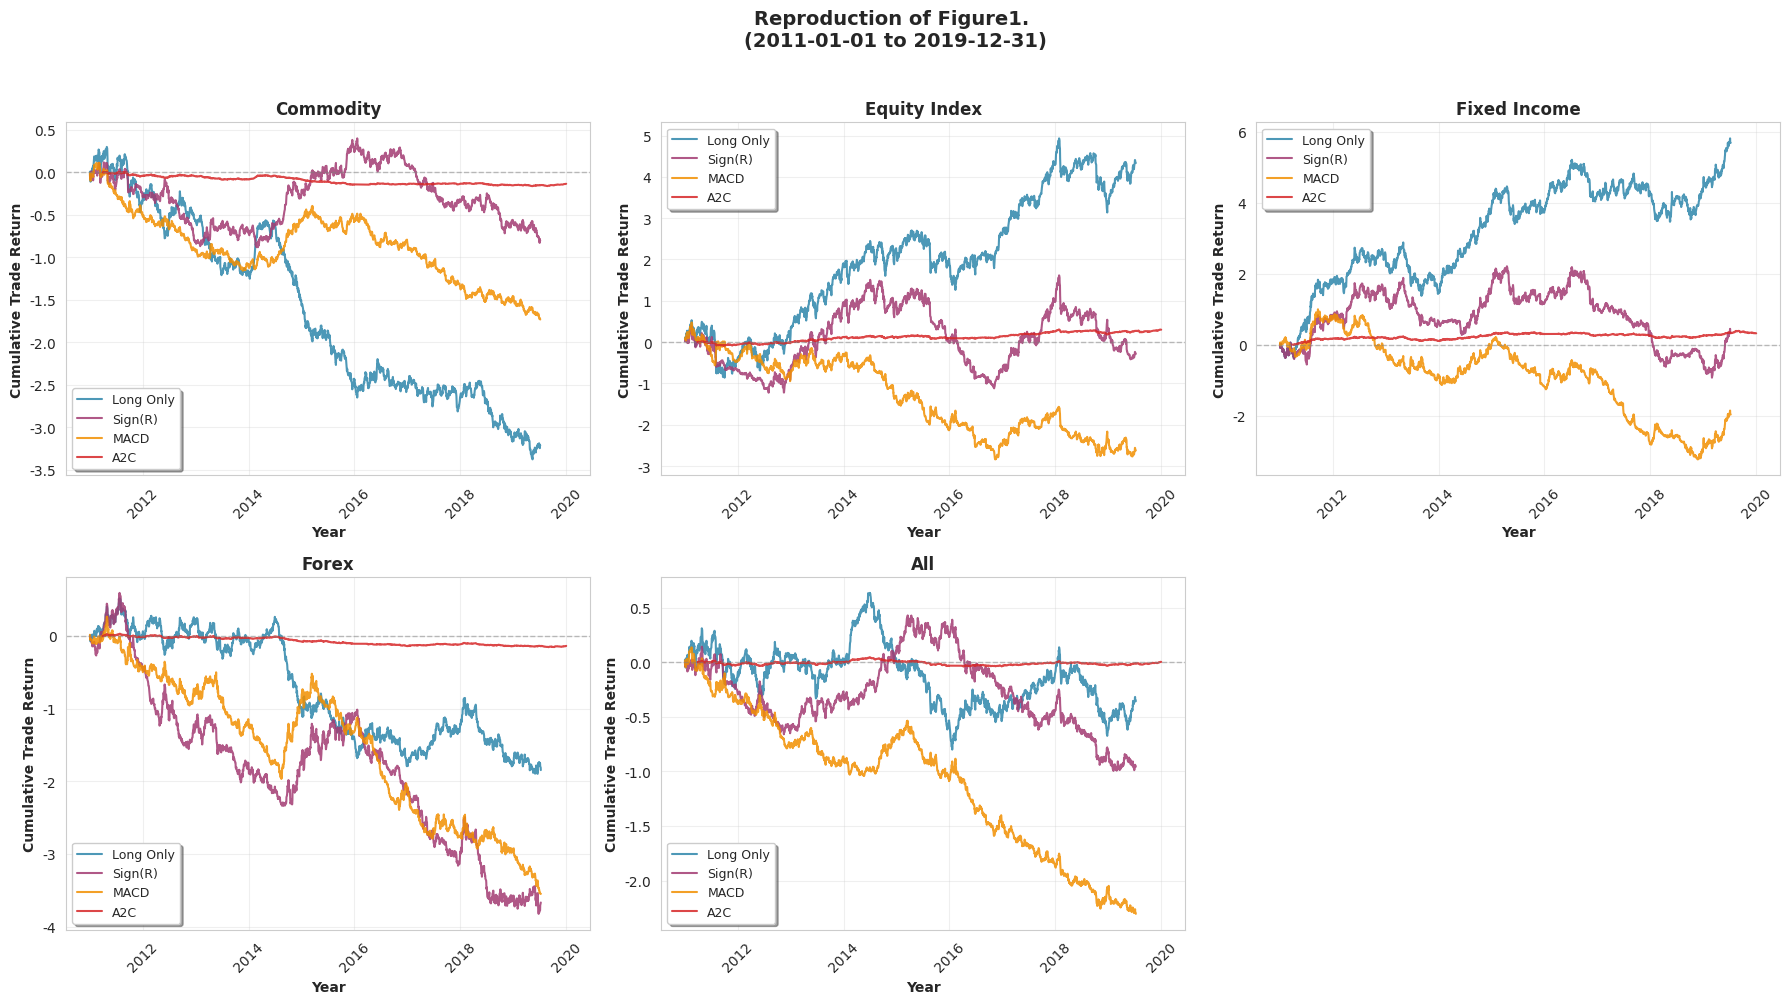

✅ 图表已保存为 strategies_by_asset_class.png


In [184]:
print("📊 生成论文风格的对比图表（5个资产类别 × 3个策略）...\n")

import matplotlib.dates as mdates

# 定义资产类别和对应的颜色
asset_order = ASSET_CLASSES_LIST + ['All']
strategy_colors = {
    'Long Only': '#2E86AB',
    'Sign(R)': '#A23B72',
    'MACD': '#F18F01',
    'A2C': '#D62728'
}

# 创建 2x3 的子图布局（5张图 + 留白）
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order):
    ax = axes[idx]
    
    # 收集该资产类别的所有策略数据
    valid_data = {}
    for strategy, results in strategies_results.items():
        dates, wealth = results.get(asset, (None, None))
        if wealth is not None:
            valid_data[strategy] = (dates, wealth)
    
    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\n数据不可用', 
                ha='center', va='center', fontsize=12, 
                transform=ax.transAxes, color='red')
        ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
        continue
    
    # 对齐所有策略的长度
    min_len = min(len(wealth) for _, wealth in valid_data.values())
    uses_datetime_axis = False
    
    # 绘制三条线
    for strategy, (dates, wealth) in valid_data.items():
        # 对齐日期和财富数据
        if dates is not None and len(dates) >= min_len:
            aligned_dates = pd.to_datetime(dates[:min_len])
            uses_datetime_axis = True
        else:
            aligned_dates = np.arange(min_len)
        
        ax.plot(aligned_dates, wealth[:min_len] - 1.0, 
                label=strategy, 
                linewidth=1.5, 
                color=strategy_colors[strategy], 
                alpha=0.85)
    
    # 设置坐标轴标签和标题
    ax.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative Trade Return', fontsize=10, fontweight='bold')
    ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, frameon=True, shadow=True)
    ax.axhline(y=0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if uses_datetime_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

# 隐藏多余的子图
for idx in range(len(asset_order), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Reproduction of Figure1. \n({TEST_START} to {TEST_END})', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(str(OUTPUT_DIR / 'strategies_by_asset_class.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ 图表已保存为 strategies_by_asset_class.png")

## Section 5: 使用纯 RAD baseline 计算策略

In [175]:
print("🔄 正在计算纯 RAD baseline 版本的策略...\n")

# 纯 RAD baseline：不使用任何 source overrides，仅保留默认排除列表
default_overrides = {}
default_excluded = EXCLUDED_CONTRACTS

baseline_results = {}

print("计算纯 RAD baseline Long Only...")
baseline_results['Long Only'] = calculate_strategy_returns_by_asset('Long', default_overrides, default_excluded)

print("计算纯 RAD baseline Sign(R)...")
baseline_results['Sign(R)'] = calculate_strategy_returns_by_asset('Sign(R)', default_overrides, default_excluded)

print("计算纯 RAD baseline MACD...")
baseline_results['MACD'] = calculate_strategy_returns_by_asset('MACD', default_overrides, default_excluded)

print("\n各资产类别 baseline 加载情况：")
for strategy, results in baseline_results.items():
    print(f"\n{strategy}:")
    for asset, (dates, wealth) in results.items():
        status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
        print(f"  • {asset:20s} {status}")

print("\n✅ 纯 RAD baseline 计算完成")

🔄 正在计算纯 RAD baseline 版本的策略...

计算纯 RAD baseline Long Only...
计算纯 RAD baseline Sign(R)...
计算纯 RAD baseline MACD...

各资产类别 baseline 加载情况：

Long Only:
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

Sign(R):
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

MACD:
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

✅ 纯 RAD baseline 计算完成


## Section 6: 纯 RAD baseline 的累积收益率对比

📊 绘制纯 RAD baseline 的对比图表（5个资产类别 × 3个策略）...



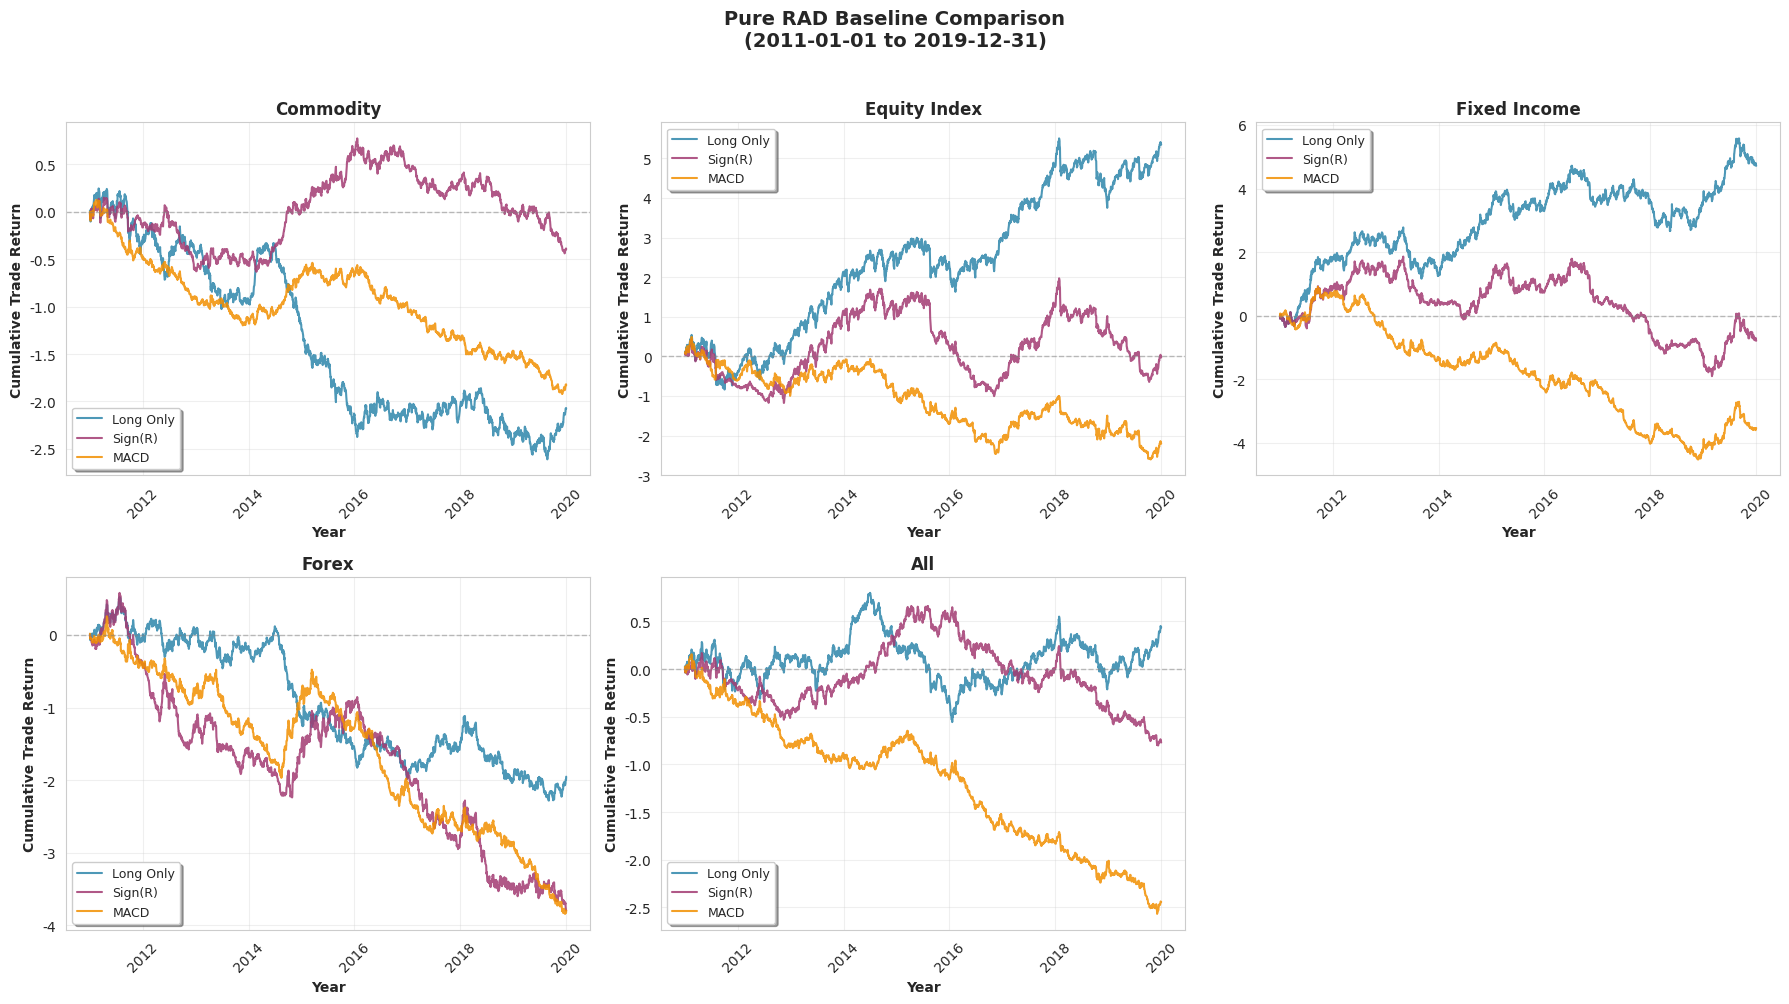

✅ 图表已保存为 strategies_pure_rad_baseline.png


In [185]:
print("📊 绘制纯 RAD baseline 的对比图表（5个资产类别 × 3个策略）...\n")

import matplotlib.dates as mdates

asset_order = ASSET_CLASSES_LIST + ['All']
strategy_colors = {
    'Long Only': '#2E86AB',
    'Sign(R)': '#A23B72',
    'MACD': '#F18F01'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order):
    ax = axes[idx]

    valid_data = {}
    for strategy, results in baseline_results.items():
        dates, wealth = results.get(asset, (None, None))
        if wealth is not None:
            valid_data[strategy] = (dates, wealth)

    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\n数据不可用',
                ha='center', va='center', fontsize=12,
                transform=ax.transAxes, color='red')
        ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
        continue

    min_len = min(len(wealth) for _, wealth in valid_data.values())
    uses_datetime_axis = False

    for strategy, (dates, wealth) in valid_data.items():
        if dates is not None and len(dates) >= min_len:
            aligned_dates = pd.to_datetime(dates[:min_len])
            uses_datetime_axis = True
        else:
            aligned_dates = np.arange(min_len)

        ax.plot(aligned_dates, wealth[:min_len] - 1.0,
                label=strategy,
                linewidth=1.5,
                color=strategy_colors[strategy],
                alpha=0.85)

    ax.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative Trade Return', fontsize=10, fontweight='bold')
    ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, frameon=True, shadow=True)
    ax.axhline(y=0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if uses_datetime_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

for idx in range(len(asset_order), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Pure RAD Baseline Comparison\n({TEST_START} to {TEST_END})',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(str(OUTPUT_DIR / 'strategies_pure_rad_baseline.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ 图表已保存为 strategies_pure_rad_baseline.png")

## Section 7: 加入 A2C 到 Pure RAD Baseline 对比图

🔄 加载 A2C 结果并重新绘制 Pure RAD Baseline 对比图（包含 A2C）...

✅ 加载 A2C Commodity           : 2143 个交易日
✅ 加载 A2C Equity Index        : 2198 个交易日
✅ 加载 A2C Fixed Income        : 2196 个交易日
✅ 加载 A2C Forex               : 2205 个交易日
✅ 加载 A2C All                 : 2206 个交易日

绘制 Pure RAD Baseline + A2C 对比图

✅ 图表已保存为 strategies_pure_rad_baseline_with_a2c.png


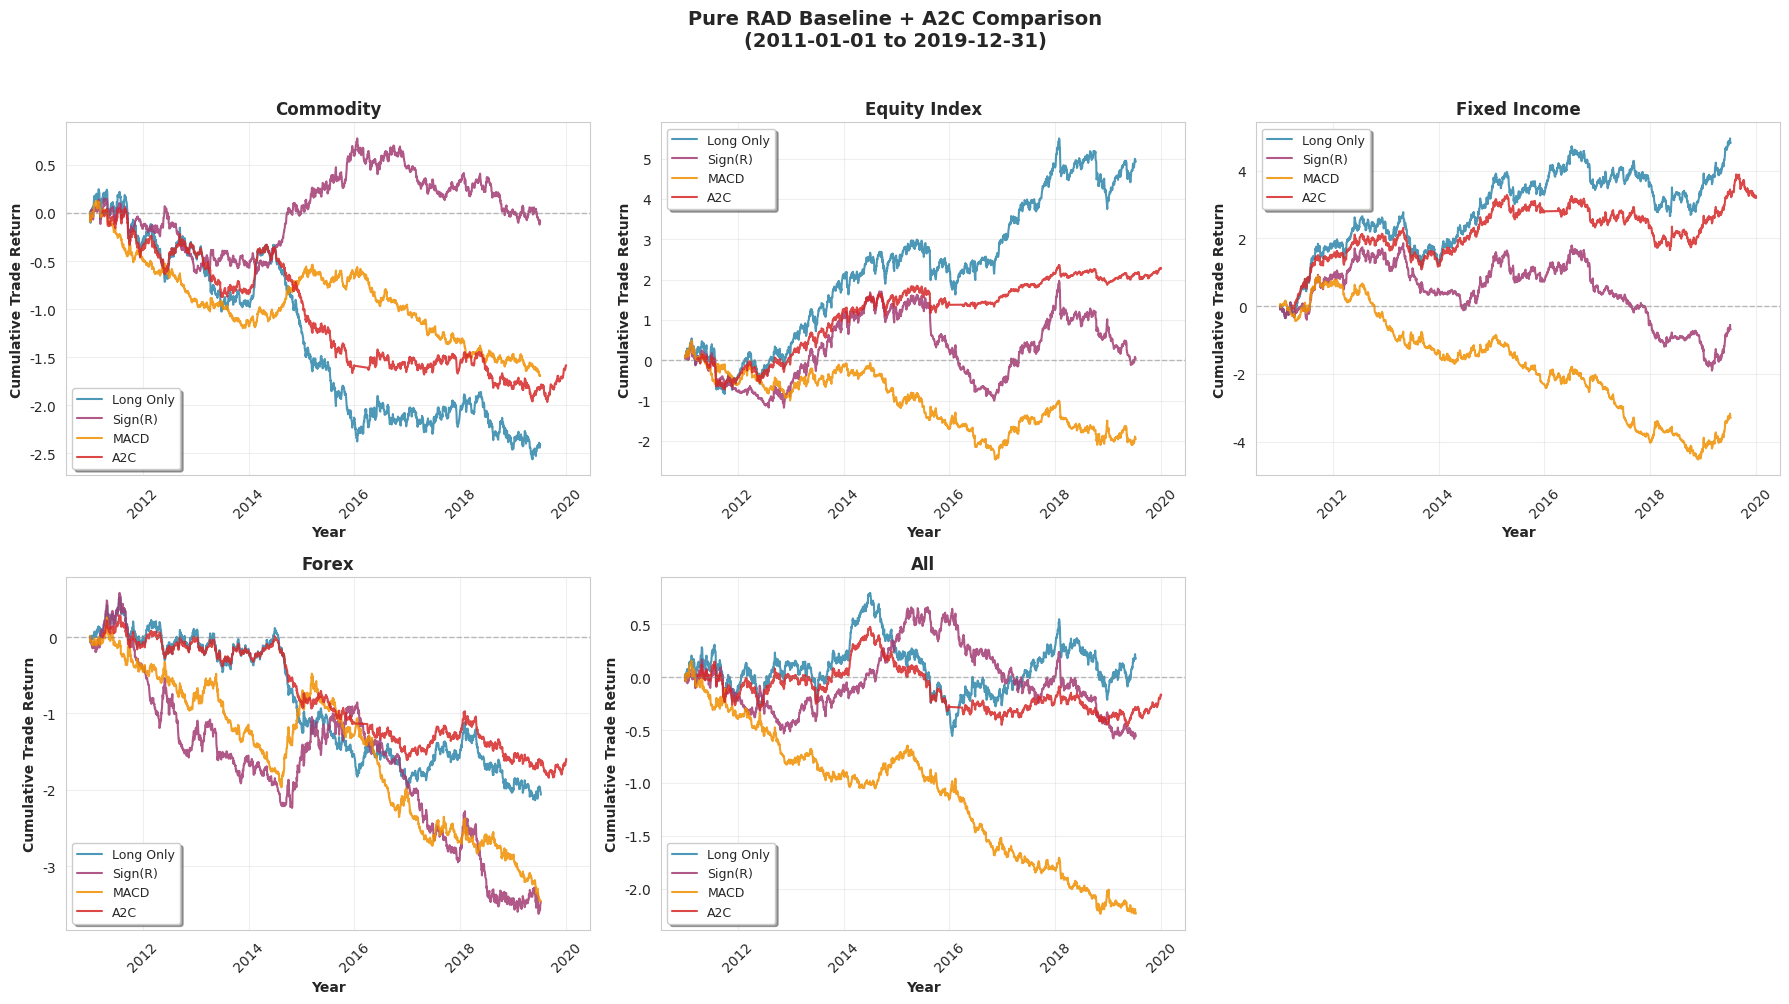

✓ Pure RAD Baseline + A2C 对比完成！


In [186]:
print("🔄 加载 A2C 结果并重新绘制 Pure RAD Baseline 对比图（包含 A2C）...\n")

# 加载 A2C 结果
a2c_wide_path = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project/rl_models/a2c_results_wide.csv')

a2c_wide_data = {}
if a2c_wide_path.exists():
    df_a2c_wide = pd.read_csv(a2c_wide_path, index_col=0)
    df_a2c_wide.index = pd.to_datetime(df_a2c_wide.index)
    
    # 转换为与其他策略一致的格式
    for asset in ASSET_CLASSES_LIST + ['All']:
        # CSV 中列名与资产类别名称一致（Forex 就是 Forex，不是 FX）
        col_name = asset
        
        if col_name in df_a2c_wide.columns:
            # 去掉 NaN 值
            series = df_a2c_wide[col_name].dropna()
            dates = series.index.to_numpy()
            wealth = series.values
            a2c_wide_data[asset] = (dates, wealth)
            print(f"✅ 加载 A2C {asset:20s}: {len(wealth)} 个交易日")
        else:
            a2c_wide_data[asset] = (None, None)
            print(f"⚠️ A2C {asset:20s}: 列不存在")
else:
    print(f"❌ 文件不存在: {a2c_wide_path}")

print("\n" + "="*80)
print("绘制 Pure RAD Baseline + A2C 对比图")
print("="*80 + "\n")

# 定义颜色（加入 A2C）
asset_order = ASSET_CLASSES_LIST + ['All']
strategy_colors_with_a2c = {
    'Long Only': '#2E86AB',
    'Sign(R)': '#A23B72',
    'MACD': '#F18F01',
    'A2C': '#D62728'  # A2C 用红色
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order):
    ax = axes[idx]
    
    # 收集该资产类别的所有策略数据（包括 A2C）
    valid_data = {}
    
    # 从 baseline_results 中获取 Long Only, Sign(R), MACD
    for strategy in ['Long Only', 'Sign(R)', 'MACD']:
        if strategy in baseline_results:
            dates, wealth = baseline_results[strategy].get(asset, (None, None))
            if wealth is not None:
                valid_data[strategy] = (dates, wealth)
    
    # 从 a2c_wide_data 中获取 A2C
    if asset in a2c_wide_data:
        dates, wealth = a2c_wide_data[asset]
        if wealth is not None:
            valid_data['A2C'] = (dates, wealth)
    
    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\n数据不可用',
                ha='center', va='center', fontsize=12,
                transform=ax.transAxes, color='red')
        ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
        continue
    
    # 对齐所有策略的长度
    min_len = min(len(wealth) for _, wealth in valid_data.values())
    uses_datetime_axis = False
    
    # 绘制所有策略的线
    for strategy, (dates, wealth) in valid_data.items():
        if dates is not None and len(dates) >= min_len:
            aligned_dates = pd.to_datetime(dates[:min_len])
            uses_datetime_axis = True
        else:
            aligned_dates = np.arange(min_len)
        
        ax.plot(aligned_dates, wealth[:min_len] - 1.0,
                label=strategy,
                linewidth=1.5,
                color=strategy_colors_with_a2c.get(strategy, '#999999'),
                alpha=0.85)
    
    ax.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative Trade Return', fontsize=10, fontweight='bold')
    ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, frameon=True, shadow=True)
    ax.axhline(y=0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    if uses_datetime_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

# 隐藏多余的子图
for idx in range(len(asset_order), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Pure RAD Baseline + A2C Comparison\n({TEST_START} to {TEST_END})',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])

output_path = OUTPUT_DIR / 'strategies_pure_rad_baseline_with_a2c.png'
plt.savefig(str(output_path), dpi=300, bbox_inches='tight')
print(f"✅ 图表已保存为 {output_path.name}")
plt.show()

print("="*80)
print("✓ Pure RAD Baseline + A2C 对比完成！")
print("="*80)


## Section 8: 加入 Route B (A2C + Regime) 到对比图

Route B 的核心改进：在原始 9-dim 状态基础上拼接 GMM soft probs `[p0, p1, p2]`，得到 12-dim 输入，训练独立的 A2C 模型。

**数据来源：**
- Regime soft probs：`regime_detection/results/regime_routeB_{period}_{asset}.csv`
- Checkpoint：`rl_models/a2c_rb_{asset}_{period}.pt`

**流程：**
1. 扫描已有 Route B checkpoint
2. 读取对应 regime soft prob CSV，构建 12-dim 测试状态
3. Deterministic inference → 每日 PnL 序列
4. 拼接 period_1 (2011-2015) 和 period_2 (2016-2019) 形成完整曲线
5. 与其他 4 个策略一起绘图对比

## Section 7.5: 加载论文原始的 DQN 数据

从 `drl/dqn/figures/data/paper_figure1_*.csv` 加载原论文的 DQN 模型结果，用于与现有的 A2C 和其他策略进行对比。


In [178]:
print("🔄 加载论文原始 DQN 数据（应用缩放因子）...\n")

# paper figure 数据路径
paper_figure_dir = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project/drl/dqn/figures/data')

# 注意：DQN 使用 PORT_VOL_TARGET = 0.97，其他策略使用 DEFAULT_SIGMA_TGT = 0.063
# 手动应用缩放因子使 DQN 与其他策略在同一量纲，范围控制在 -4 到 +6
DISPLAY_SCALE_FACTOR = 0.40  # 缩小 DQN 到原来的 20%

dqn_results = {}

# 加载单个资产类别
individual_assets = {
    'Commodity': 'paper_figure1_commodity_bp20.csv',
    'Equity Index': 'paper_figure1_equity index_bp20.csv',
    'Fixed Income': 'paper_figure1_fixed income_bp20.csv',
    'Forex': 'paper_figure1_forex_bp20.csv',
}

# 加载每个资产类别
for asset, filename in individual_assets.items():
    csv_path = paper_figure_dir / filename
    
    if not csv_path.exists():
        print(f'  ⚠️  {asset:20s}: 文件不存在 ({filename})')
        dqn_results[asset] = (None, None)
        continue
    
    df = pd.read_csv(csv_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').drop_duplicates(subset=['date'], keep='first')
    
    if len(df) == 0:
        print(f'  ⚠️  {asset:20s}: 无有效数据')
        dqn_results[asset] = (None, None)
        continue
    
    # 应用缩放因子到原始累积收益数据
    dates = df['date'].values
    cum_returns = df['DQN_cum_return'].values
    scaled_cum_returns = cum_returns * DISPLAY_SCALE_FACTOR
    wealth = 1.0 + scaled_cum_returns
    dqn_results[asset] = (dates, wealth)
    
    print(f'  ✅ {asset:20s}: {len(wealth):5d} 交易日 | 范围: [{wealth.min():6.2f}, {wealth.max():6.2f}]')

# 加载 All 资产（从单独的 CSV 文件）
csv_path_all = paper_figure_dir / 'paper_figure1_all_bp20.csv'
if csv_path_all.exists():
    df_all = pd.read_csv(csv_path_all)
    df_all['date'] = pd.to_datetime(df_all['date'])
    df_all = df_all.sort_values('date').drop_duplicates(subset=['date'], keep='first')
    
    if len(df_all) > 0:
        dates_all = df_all['date'].values
        cum_returns_all = df_all['DQN_cum_return'].values
        scaled_cum_returns_all = cum_returns_all * DISPLAY_SCALE_FACTOR
        wealth_all = 1.0 + scaled_cum_returns_all
        dqn_results['All'] = (dates_all, wealth_all)
        print(f'  ✅ {"All":20s}: {len(wealth_all):5d} 交易日 | 范围: [{wealth_all.min():6.2f}, {wealth_all.max():6.2f}] (平均)')
    else:
        dqn_results['All'] = (None, None)
        print(f'  ⚠️  {"All":20s}: 无有效数据')
else:
    print(f'  ⚠️  {"All":20s}: 文件不存在')
    dqn_results['All'] = (None, None)

n_ok = sum(1 for v in dqn_results.values() if v[0] is not None)
print(f'\n✅ DQN 数据加载完成：{n_ok}/{len(dqn_results)} 个资产类别')
print(f'📌 显示缩放因子: {DISPLAY_SCALE_FACTOR} (→ 原来的 {DISPLAY_SCALE_FACTOR*100:.0f}%)')


🔄 加载论文原始 DQN 数据（应用缩放因子）...

  ✅ Commodity           :  2267 交易日 | 范围: [ -2.40,   1.33]
  ✅ Equity Index        :  2322 交易日 | 范围: [ -1.01,   1.29]
  ✅ Fixed Income        :  2321 交易日 | 范围: [  0.62,   2.41]
  ✅ Forex               :  2329 交易日 | 范围: [ -4.83,   1.38]
  ✅ All                 :  2267 交易日 | 范围: [ -1.77,   1.18] (平均)

✅ DQN 数据加载完成：5/5 个资产类别
📌 显示缩放因子: 0.4 (→ 原来的 40%)


## Section 7.6: 5 策略对比图（不含 Route B）

绘制包含 Long Only、Sign(R)、MACD、A2C 和 DQN 的对比图（不包含 Route B）


📊 绘制 5 策略对比图（不含 Route B）...



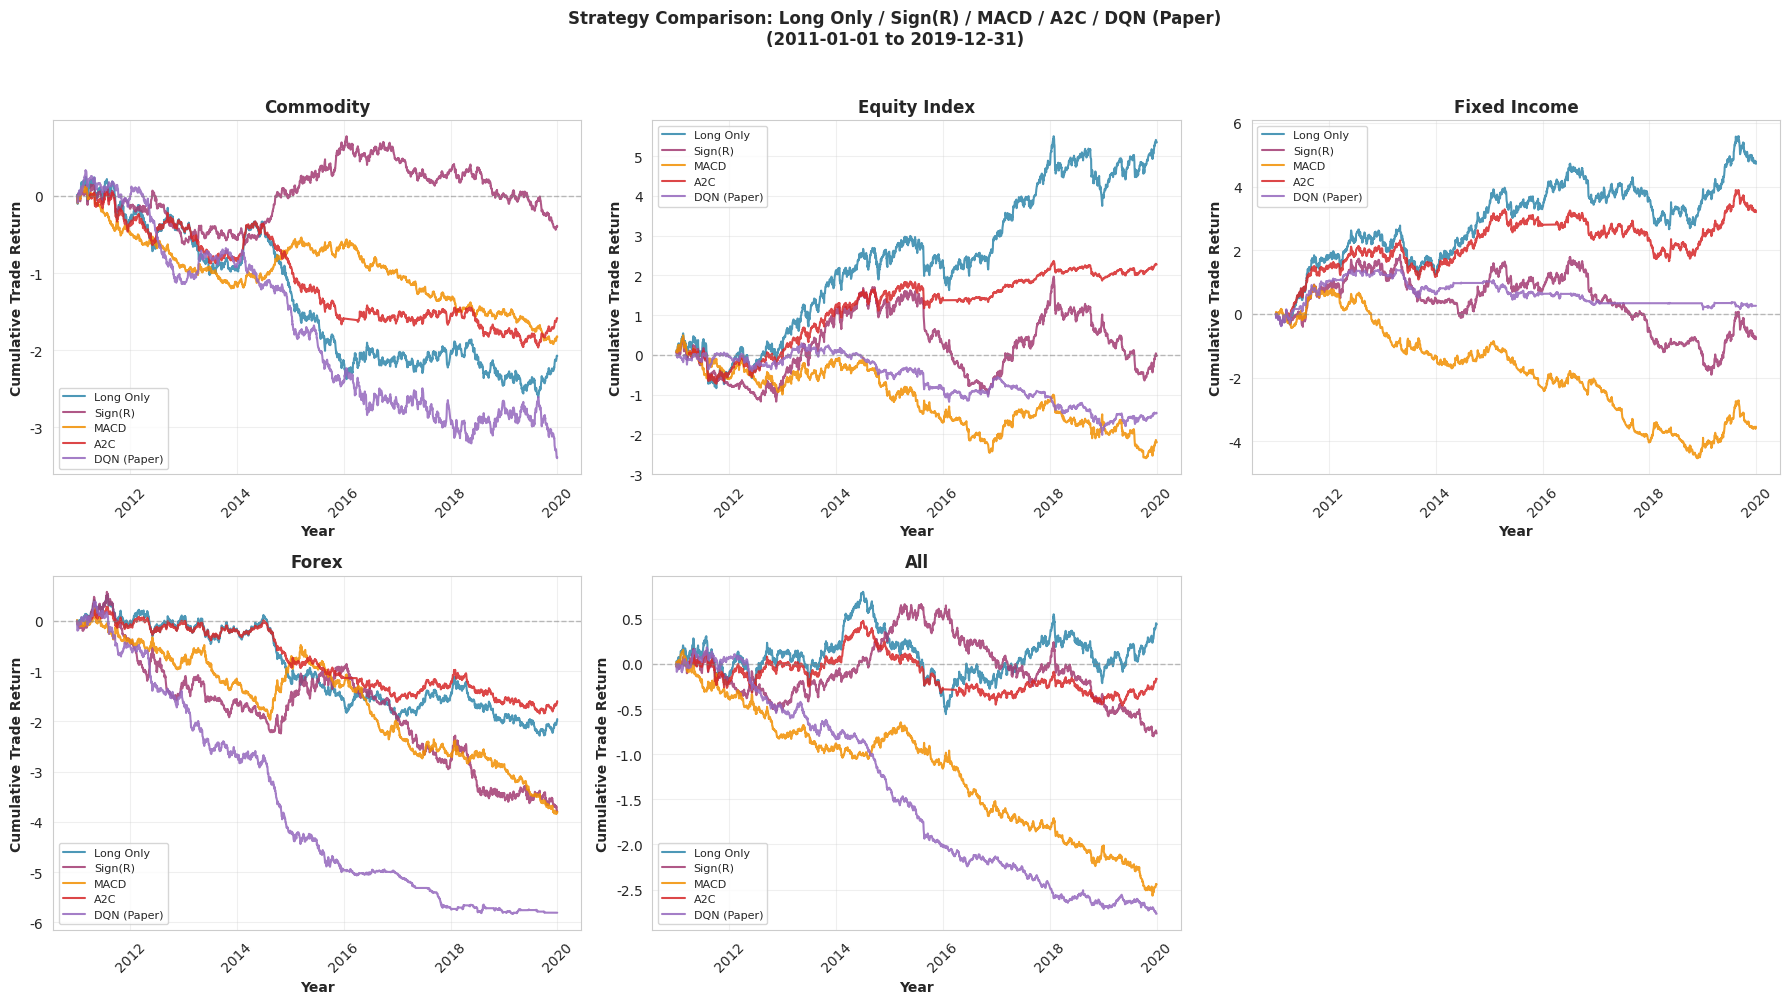

✅ 图表已保存为 strategies_5_comparison_no_routeb.png


In [187]:
import matplotlib.dates as mdates
print('📊 绘制 5 策略对比图（不含 Route B）...\n')

asset_order_plot = ASSET_CLASSES_LIST + ['All']

COLORS_5_STRATEGIES = {
    'Long Only':        '#2E86AB',
    'Sign(R)':          '#A23B72',
    'MACD':             '#F18F01',
    'A2C':              '#D62728',
    'DQN (Paper)':      '#9467BD',
}

all_strategy_data_5 = {
    'Long Only':        baseline_results.get('Long Only', {}),
    'Sign(R)':          baseline_results.get('Sign(R)', {}),
    'MACD':             baseline_results.get('MACD', {}),
    'A2C':              a2c_wide_data,
    'DQN (Paper)':      dqn_results,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order_plot):
    ax = axes[idx]
    valid_data = {}

    for strategy, results in all_strategy_data_5.items():
        entry = results.get(asset, (None, None))
        dates_e, wealth_e = entry if isinstance(entry, tuple) else (None, None)
        if wealth_e is not None:
            valid_data[strategy] = (dates_e, wealth_e)

    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\n数据不可用',
                ha='center', va='center', fontsize=12,
                transform=ax.transAxes, color='red')
        ax.set_title(asset, fontsize=12, fontweight='bold')
        continue

    uses_datetime_axis = False
    for strategy, (dates_e, wealth_e) in valid_data.items():
        lw    = 1.5
        alpha = 0.85

        if dates_e is not None and len(dates_e) > 0:
            try:
                if isinstance(dates_e, np.ndarray) and dates_e.dtype.kind == 'M':
                    aligned_dates = pd.to_datetime(dates_e)
                else:
                    aligned_dates = pd.to_datetime(dates_e)
                uses_datetime_axis = True
            except Exception as e:
                print(f"⚠️ 日期转换失败 ({strategy}): {e}")
                aligned_dates = np.arange(len(wealth_e))
        else:
            aligned_dates = np.arange(len(wealth_e))

        ax.plot(aligned_dates, wealth_e - 1.0,
                label=strategy,
                linewidth=lw,
                color=COLORS_5_STRATEGIES.get(strategy, '#888888'),
                alpha=alpha)

    ax.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative Trade Return', fontsize=10, fontweight='bold')
    ax.set_title(asset, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8, frameon=True)
    ax.axhline(y=0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if uses_datetime_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

for idx in range(len(asset_order_plot), len(axes)):
    axes[idx].axis('off')

plt.suptitle(
    'Strategy Comparison: Long Only / Sign(R) / MACD / A2C / DQN (Paper)\n'
    f'({TEST_START} to {TEST_END})',
    fontsize=12, fontweight='bold', y=1.00
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
out_path = OUTPUT_DIR / 'strategies_5_comparison_no_routeb.png'
plt.savefig(str(out_path), dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ 图表已保存为 {out_path.name}')


## Section 8: 加载 Route B (A2C + Regime) 并绘制 6 策略完整对比图

加载 Route B 数据，绘制包含所有 6 个策略的完整对比图：Long Only、Sign(R)、MACD、A2C、Route B 和 DQN


In [182]:
from pathlib import Path
import numpy as np
from config import ASSET_CLASSES

REGIME_RESULTS_DIR = ROOT / 'regime_detection' / 'results'

ASSET_CLASSES_WITH_ALL_RB = dict(ASSET_CLASSES)
ASSET_CLASSES_WITH_ALL_RB['All'] = [t for tickers in ASSET_CLASSES.values() for t in tickers]

# 统一 sigma_target：Route B 与 A2C 对齐到同一基准 0.064（日度），不再缩放
RB_SIGMA_TARGET  = 0.064
# A2C baseline（a2c_results_wide.csv）用的 sigma_target
A2C_SIGMA_TARGET = 0.064
# PNL_SCALE = 1.0，两者 sigma_target 已对齐，无需缩放
PNL_SCALE = A2C_SIGMA_TARGET / RB_SIGMA_TARGET   # = 1.0
print(f'PnL scale factor: {PNL_SCALE:.4f}  (RB σ={RB_SIGMA_TARGET} == A2C σ={A2C_SIGMA_TARGET}, no rescaling)')

# 🔥 定义各 period 的 test 段时间范围（仅绘制 test 数据，不要 warmup 的 2004-2010）
PERIOD_TEST_RANGES = {
    'period_1': ('2011-01-01', '2015-12-31'),
    'period_2': ('2016-01-01', '2019-12-31'),
}

route_b_results = {}

for asset_class in list(ASSET_CLASSES_WITH_ALL_RB.keys()):
    ac_slug   = asset_class.replace(' ', '_')
    segments  = []

    for period_name in ['period_1', 'period_2']:
        csv_path = REGIME_RESULTS_DIR / f'pnl_routeB_{period_name}_{ac_slug}.csv'
        if not csv_path.exists():
            print(f'  ⚠️  {asset_class} | {period_name}: 文件不存在 ({csv_path.name})')
            continue
        df  = pd.read_csv(csv_path, parse_dates=['date'])
        
        # 🔥 仅保留 test 段数据（不要 2004-2010 的 warmup 数据）
        test_start, test_end = PERIOD_TEST_RANGES[period_name]
        df = df[(df['date'] >= test_start) & (df['date'] <= test_end)]
        
        if len(df) == 0:
            print(f'  ⚠️  {asset_class} | {period_name}: 在 test 段 [{test_start}~{test_end}] 内无数据')
            continue
        
        # 乘以缩放因子，对齐到 A2C 的 position sizing 基准
        pnl = pd.Series(df['net_pnl'].values * PNL_SCALE, index=df['date'])
        segments.append(pnl)
        print(f'  ✅ {asset_class:<18} | {period_name}: {len(pnl)} 行 (test {test_start}~{test_end})  '
              f'(ann_std≈{pnl.std()*np.sqrt(252):.4f})')

    if not segments:
        route_b_results[asset_class] = (None, None)
        continue

    combined = pd.concat(segments).sort_index()
    combined = combined[~combined.index.duplicated(keep='first')]
    dates    = combined.index.to_numpy()
    wealth   = 1.0 + np.cumsum(combined.values)
    route_b_results[asset_class] = (dates, wealth)

n_ok = sum(1 for v in route_b_results.values() if v[0] is not None)
print(f'\n✅ Route B 财富曲线已就绪：{n_ok}/{len(route_b_results)} 个资产类别')

if n_ok == 0:
    print('\n  ⚠️  未找到任何 CSV。')
    print('     请先运行 route_b_experiment.ipynb 的 Section 5 + Section 6，')
    print('     再回来重新运行此单元格。')


PnL scale factor: 1.0000  (RB σ=0.064 == A2C σ=0.064, no rescaling)
  ✅ Commodity          | period_1: 1260 行 (test 2011-01-01~2015-12-31)  (ann_std≈0.3214)
  ✅ Commodity          | period_2: 1007 行 (test 2016-01-01~2019-12-31)  (ann_std≈0.2726)
  ✅ Equity Index       | period_1: 1290 行 (test 2011-01-01~2015-12-31)  (ann_std≈0.6799)
  ✅ Equity Index       | period_2: 1032 行 (test 2016-01-01~2019-12-31)  (ann_std≈0.6092)
  ✅ Fixed Income       | period_1: 1289 行 (test 2011-01-01~2015-12-31)  (ann_std≈0.7146)
  ✅ Fixed Income       | period_2: 1032 行 (test 2016-01-01~2019-12-31)  (ann_std≈0.7123)
  ✅ Forex              | period_1: 1293 行 (test 2011-01-01~2015-12-31)  (ann_std≈0.3658)
  ✅ Forex              | period_2: 1036 行 (test 2016-01-01~2019-12-31)  (ann_std≈0.3305)
  ✅ All                | period_1: 1293 行 (test 2011-01-01~2015-12-31)  (ann_std≈0.0602)
  ✅ All                | period_2: 1037 行 (test 2016-01-01~2019-12-31)  (ann_std≈0.2552)

✅ Route B 财富曲线已就绪：5/5 个资产类别


📊 绘制含 Route B 和 DQN 论文数据的完整对比图...



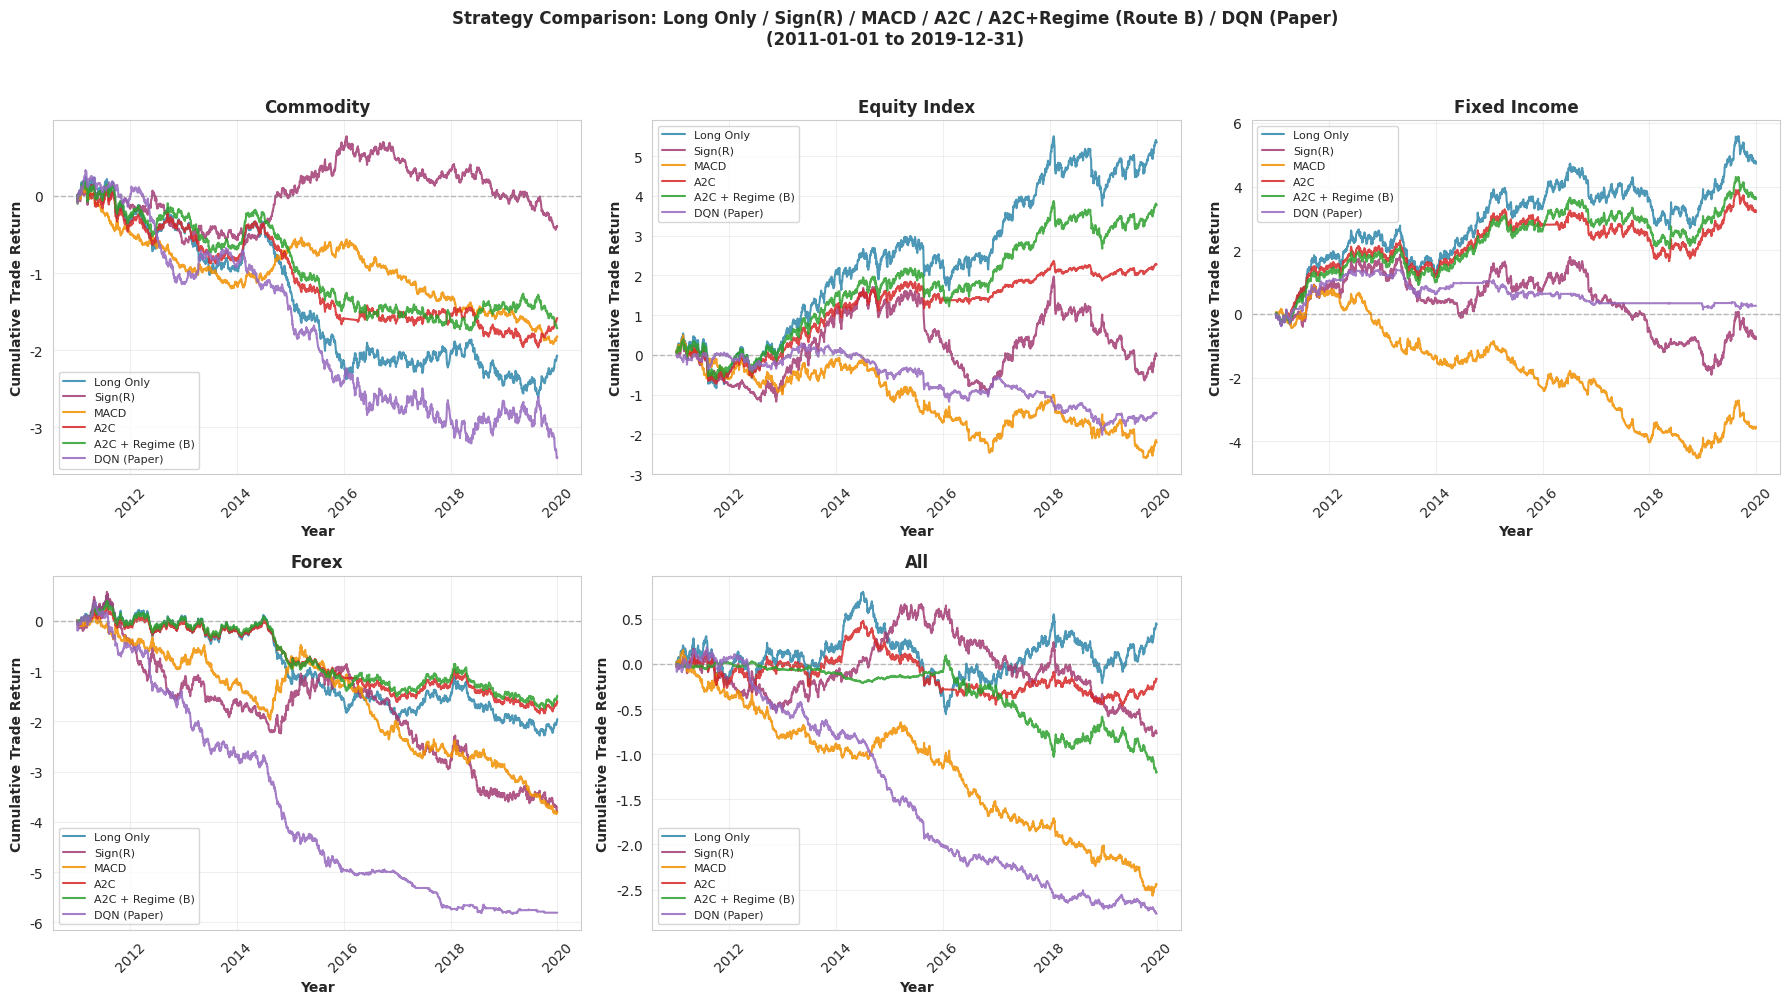

✅ 图表已保存为 strategies_with_route_b_and_dqn.png


In [188]:
import matplotlib.dates as mdates
print('📊 绘制含 Route B 和 DQN 论文数据的完整对比图...\n')

asset_order_plot = ASSET_CLASSES_LIST + ['All']

COLORS_FULL = {
    'Long Only':        '#2E86AB',
    'Sign(R)':          '#A23B72',
    'MACD':             '#F18F01',
    'A2C':              '#D62728',
    'A2C + Regime (B)': '#2CA02C',
    'DQN (Paper)':      '#9467BD',  # 论文原始 DQN，用紫色区分（与 MACD 橙色区别）
}

all_strategy_data = {
    'Long Only':        baseline_results.get('Long Only', {}),
    'Sign(R)':          baseline_results.get('Sign(R)', {}),
    'MACD':             baseline_results.get('MACD', {}),
    'A2C':              a2c_wide_data,
    'A2C + Regime (B)': route_b_results,
    'DQN (Paper)':      dqn_results,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order_plot):
    ax = axes[idx]
    valid_data = {}

    for strategy, results in all_strategy_data.items():
        entry = results.get(asset, (None, None))
        dates_e, wealth_e = entry if isinstance(entry, tuple) else (None, None)
        if wealth_e is not None:
            valid_data[strategy] = (dates_e, wealth_e)

    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\n数据不可用',
                ha='center', va='center', fontsize=12,
                transform=ax.transAxes, color='red')
        ax.set_title(asset, fontsize=12, fontweight='bold')
        continue

    uses_datetime_axis = False
    for strategy, (dates_e, wealth_e) in valid_data.items():
        # 所有线统一粗细，不再单独加粗 Route B
        lw    = 1.5
        alpha = 0.85

        if dates_e is not None and len(dates_e) > 0:
            try:
                # 确保转换为 datetime，处理 numpy datetime64 数组
                if isinstance(dates_e, np.ndarray) and dates_e.dtype.kind == 'M':
                    aligned_dates = pd.to_datetime(dates_e)
                else:
                    aligned_dates = pd.to_datetime(dates_e)
                uses_datetime_axis = True
            except Exception as e:
                print(f"⚠️ 日期转换失败 ({strategy}): {e}")
                aligned_dates = np.arange(len(wealth_e))
        else:
            aligned_dates = np.arange(len(wealth_e))

        ax.plot(aligned_dates, wealth_e - 1.0,
                label=strategy,
                linewidth=lw,
                color=COLORS_FULL.get(strategy, '#888888'),
                alpha=alpha)

    ax.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative Trade Return', fontsize=10, fontweight='bold')
    ax.set_title(asset, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8, frameon=True)
    ax.axhline(y=0.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if uses_datetime_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

for idx in range(len(asset_order_plot), len(axes)):
    axes[idx].axis('off')

plt.suptitle(
    'Strategy Comparison: Long Only / Sign(R) / MACD / A2C / A2C+Regime (Route B) / DQN (Paper)\n'
    f'({TEST_START} to {TEST_END})',
    fontsize=12, fontweight='bold', y=1.00
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
out_path = OUTPUT_DIR / 'strategies_with_route_b_and_dqn.png'
plt.savefig(str(out_path), dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ 图表已保存为 {out_path.name}')
